In [2]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load Iris dataset
iris = load_iris()  # Bunch object containing data, target, feature names, etc.
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: 0=setosa, 1=versicolor, 2=virginica

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)  # Create DataFrame with proper column names
df['species'] = y  # Add numeric species codes as a column
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})  # Map codes to species names

# Display dataset information
print("Dataset shape:", df.shape)  # Print dimensions (rows, columns)
print("\nFirst 5 rows:")  # Header for preview section
print(df.head())  # Show first 5 rows to verify data
print("\nTarget distribution:")  # Header for distribution section
print(df['species_name'].value_counts())  # Count samples per species (balanced: 50 each)

Dataset shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Target distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 120 samples
Test set: 30 samples


### Train Decision Tree (Baseline)

In [6]:
# Train a single Decision Tree for comparison
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=iris.target_names))


DECISION TREE RESULTS
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Train Random Forest

In [8]:
# Import Random Forest classifier from scikit-learn
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with key parameters
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of decision trees in the forest (100 trees total)
    max_features='sqrt',     # Number of features to consider per split: sqrt(total features) = sqrt(4) = 2 features
    bootstrap=True,          # Use bootstrap sampling (sample with replacement) for each tree
    oob_score=True,          # Calculate Out-Of-Bag score (uses ~37% of data not in bootstrap as validation)
    random_state=42,         # Fix random seed for reproducible results
    n_jobs=-1                # Use all available CPU cores for parallel processing (-1 = all cores)
)

# Train the Random Forest model on training data
# Builds 100 decision trees, each on a different bootstrap sample of the data
rf_model.fit(X_train, y_train)

# Evaluate model using Out-Of-Bag score (built-in cross-validation)
# OOB samples are data points NOT included in each tree's bootstrap sample
print("=" * 50)                      # Print visual separator line (50 equal signs)
print("RANDOM FOREST - TRAINING")    # Print section header
print("=" * 50)                      # Print visual separator line
print(f"OOB Score (built-in): {rf_model.oob_score_:.4f}")  # Print OOB accuracy (0.0 to 1.0)
print(f"OOB Error: {1 - rf_model.oob_score_:.4f}")         # Print OOB error rate (1 - accuracy)

RANDOM FOREST - TRAINING
OOB Score (built-in): 0.9417
OOB Error: 0.0583


### Evaluate Random Forest


In [9]:
# Predict on test set
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n" + "=" * 50)
print("RANDOM FOREST - TEST RESULTS")
print("=" * 50)
print(f"Test Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=iris.target_names))


RANDOM FOREST - TEST RESULTS
Test Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Confusion Matrix

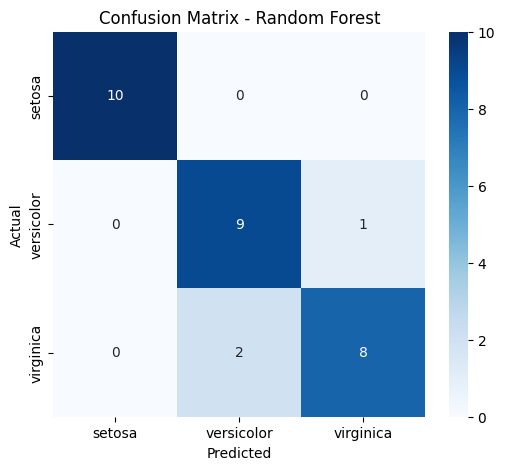

In [26]:

# Calculate confusion matrix by comparing actual vs predicted values
# y_test: True labels from test set
# rf_pred: Predicted labels from Random Forest model
cm = confusion_matrix(y_test, rf_pred)

# Create a new figure with custom size
# figsize = (width_inches, height_inches) - makes plot 6x5 inches
plt.figure(figsize=(6, 5))

# Create a heatmap visualization of the confusion matrix
sns.heatmap(
    cm,                          # Confusion matrix data to plot
    annot=True,                  # Display the numeric values in each cell
    fmt='d',                     # Format numbers as integers (no decimal places)
    cmap='Blues',                # Color scheme (light blue to dark blue)
    xticklabels=iris.target_names,  # Labels for x-axis: 'setosa', 'versicolor', 'virginica'
    yticklabels=iris.target_names   # Labels for y-axis: 'setosa', 'versicolor', 'virginica'
)

# Add a title to the plot
plt.title('Confusion Matrix - Random Forest')

# Label the x-axis (what the model predicted)
plt.xlabel('Predicted')

# Label the y-axis (actual true values)
plt.ylabel('Actual')

# Display the plot on screen
plt.show()

### Model Performance Summary

The Random Forest model achieved **90% overall accuracy** (27 correct out of 30 predictions).

| Metric | Result |
|--------|--------|
| Total samples | 30 |
| Correct predictions | 27 |
| Wrong predictions | 3 |
| Accuracy | 90% |

### Per-Species Performance

| Species | Correct | Wrong | Performance |
|---------|---------|-------|-------------|
| **Setosa** | 10/10 | 0 | ✅ Perfect |
| **Versicolor** | 9/10 | 1 | ⚠️ 1 misclassified as Virginica |
| **Virginica** | 8/10 | 2 | ⚠️ 2 misclassified as Versicolor |

### What This Tells Us

- **Setosa** is perfectly identified - no mistakes
- **Versicolor** and **Virginica** are slightly confused with each other
- The model struggles most with distinguishing Versicolor from Virginica (3 total errors between them)
- This is expected because Setosa looks very different, while Versicolor and Virginica are more similar

### Compare Decision Tree vs Random Forest

In [27]:
print("\n" + "=" * 50)
print("DT vs RF COMPARISON")
print("=" * 50)
print(f"Decision Tree Accuracy:  {dt_accuracy:.4f}")
print(f"Random Forest Accuracy:  {rf_accuracy:.4f}")
print(f"Improvement:             {(rf_accuracy - dt_accuracy):.4f}")


DT vs RF COMPARISON
Decision Tree Accuracy:  0.9333
Random Forest Accuracy:  0.9000
Improvement:             -0.0333


In [28]:
# Performance difference explanation
if rf_accuracy > dt_accuracy:
    print("\n✅ Random Forest performs better due to:")
    print("   - Reduced overfitting (ensemble averaging)")
    print("   - Feature randomness (less correlated trees)")
    print("   - Bootstrap sampling (different training sets)")
else:
    print("Decision Tree performed equally or better (unusual for Iris)")

Decision Tree performed equally or better (unusual for Iris)


### Feature Importances – Bar Chart

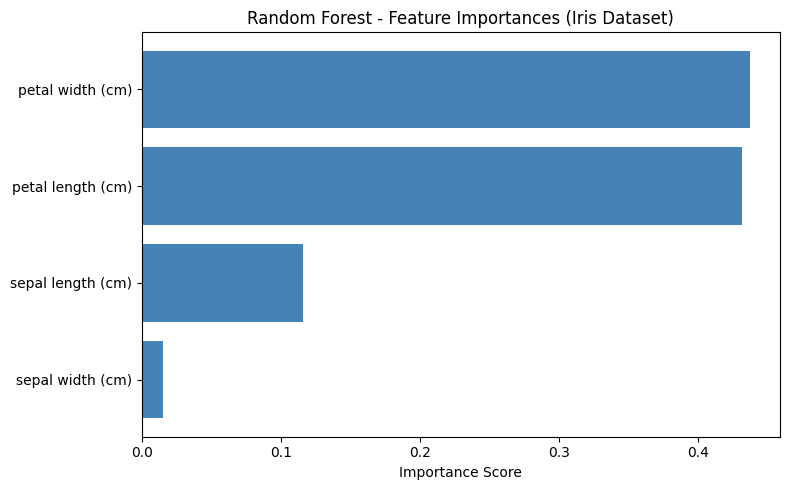


FEATURE IMPORTANCES
sepal length (cm)   : 0.1163
sepal width (cm)    : 0.0150
petal length (cm)   : 0.4315
petal width (cm)    : 0.4372


In [ ]:
# EXTRACT FEATURE IMPORTANCES FROM TRAINED MODEL
# feature_importances_ is a built-in attribute of Random Forest
# Higher value = more important for making predictions
# All values sum to 1.0 (100% of importance)
feature_importances = rf_model.feature_importances_

# Get the names of the 4 features from the Iris dataset
# ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
feature_names = iris.feature_names

# SORT FEATURES FOR BETTER VISUALIZATION
# np.argsort returns indices that would sort the array from smallest to largest
# Example: if importances = [0.1, 0.6, 0.05, 0.25]
# argsort returns [2, 0, 3, 1] (index 2 has smallest value 0.05)
sorted_idx = np.argsort(feature_importances)

# CREATE HORIZONTAL BAR CHART
# Create figure with custom size (8 inches wide, 5 inches tall)
plt.figure(figsize=(8, 5))

# Draw horizontal bars:
# - range(4) creates y-axis positions [0, 1, 2, 3]
# - feature_importances[sorted_idx] puts smallest importance at top
# - color='steelblue' makes bars a professional blue color
plt.barh(range(len(feature_importances)), feature_importances[sorted_idx], color='steelblue')

# Set labels on y-axis:
# - Positions: [0, 1, 2, 3]
# - Labels: feature names ordered from least to most important
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])

# Label the x-axis (importance scores range from 0 to 1)
plt.xlabel('Importance Score')

# Add title to the chart
plt.title('Random Forest - Feature Importances (Iris Dataset)')

# Automatically adjust spacing to prevent labels from being cut off
plt.tight_layout()

# Display the chart on screen
plt.show()

# PRINT NUMERIC VALUES IN CONSOLE
# Print separator line (50 equal signs) with a blank line before
print("\n" + "=" * 50)
print("FEATURE IMPORTANCES")
print("=" * 50)

# Loop through all features and their importance scores
# zip() pairs each feature name with its importance value
for name, importance in zip(feature_names, feature_importances):
    # Print with formatting:
    # - name: left-aligned in 20 character width
    # - importance: 4 decimal places
    print(f"{name:20}: {importance:.4f}")

Decision Tree Accuracy: 0.9333
Random Forest Accuracy: 0.9000
OOB Score: 0.9417


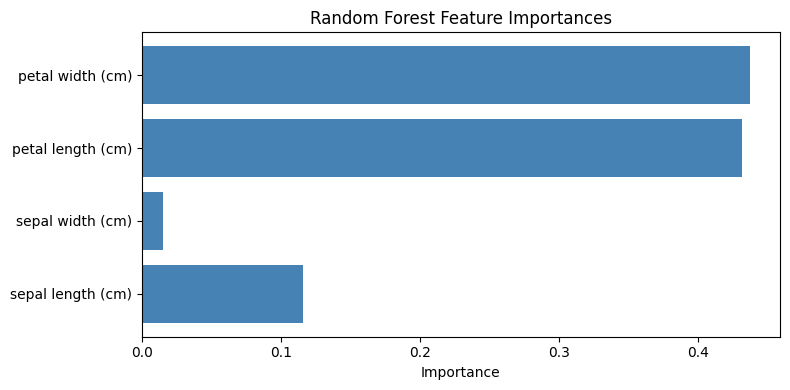

In [30]:
# ============================================
# COMPLETE RANDOM FOREST CODE - IRIS DATASET
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set seed for reproducibility
np.random.seed(42)

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100, 
    max_features='sqrt', 
    bootstrap=True, 
    oob_score=True, 
    random_state=42
)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# Results
print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")

# Feature importances plot
plt.figure(figsize=(8, 4))
plt.barh(iris.feature_names, rf.feature_importances_, color='steelblue')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()